# **Import Data**

In [ ]:
import pandas as pd

data = pd.read_excel("Employees.xlsx")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   No              689 non-null    int64         
 1   First Name      689 non-null    object        
 2   Last Name       689 non-null    object        
 3   Gender          689 non-null    object        
 4   Start Date      689 non-null    datetime64[ns]
 5   Years           689 non-null    int64         
 6   Department      689 non-null    object        
 7   Country         689 non-null    object        
 8   Center          689 non-null    object        
 9   Monthly Salary  689 non-null    int64         
 10  Annual Salary   689 non-null    int64         
 11  Job Rate        689 non-null    float64       
 12  Sick Leaves     689 non-null    int64         
 13  Unpaid Leaves   689 non-null    int64         
 14  Overtime Hours  689 non-null    int64         
dtypes: dat

In [ ]:
data.shape

(689, 15)

# **Data Cleaning**

In [ ]:
data.isna().sum()

,0
No,0
First Name,0
Last Name,0
Gender,0
Start Date,0
Years,0
Department,0
Country,0
Center,0
Monthly Salary,0


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

# **Data Visualization**

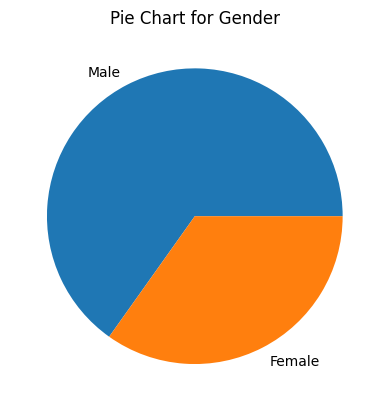

In [ ]:
import matplotlib.pyplot as plt

data["Gender"].value_counts().plot(kind="pie")

plt.title ("Pie Chart for Gender")
plt.ylabel("")
plt.show()

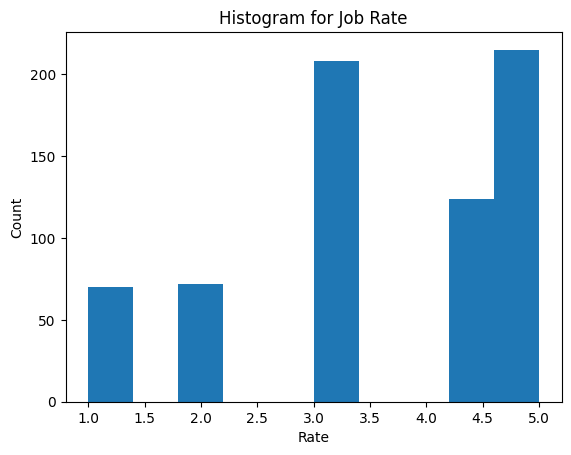

In [ ]:
plt.hist(data["Job Rate"])
plt.title("Histogram for Job Rate")
plt.xlabel("Rate")
plt.ylabel("Count")
plt.show()

In [ ]:
data["Job Rate"].describe()

,Job Rate
count,689.000000
mean,3.586357
std,1.350125
min,1.000000
25%,3.000000
50%,3.000000
75%,5.000000
max,5.000000


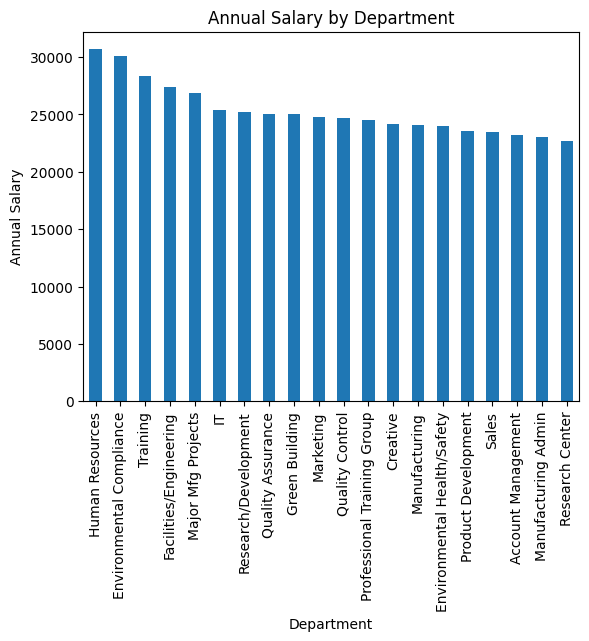

In [ ]:
data.groupby("Department")["Annual Salary"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Annual Salary by Department")
plt.xlabel("Department")
plt.ylabel("Annual Salary")
plt.show()

In [ ]:
data.groupby("Center")["Monthly Salary"].mean().sort_values(ascending=False)

,Monthly Salary
Center,
East,2274.021277
West,2068.672269
North,2064.811594
Main,2054.776892
South,1981.153846


In [ ]:
data["Country"].unique()

array(['Egypt', 'Saudi Arabia', 'United Arab Emirates', 'Syria',
       'Lebanon'], dtype=object)

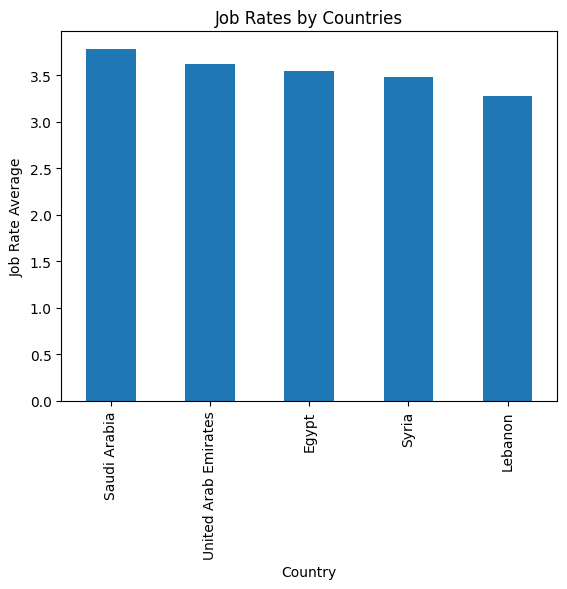

In [ ]:
data.groupby("Country")["Job Rate"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Job Rates by Countries")
plt.xlabel("Country")
plt.ylabel("Job Rate Average")
plt.show()

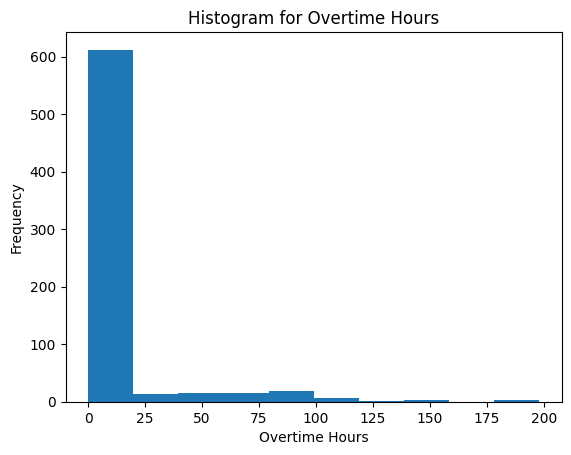

In [ ]:
plt.hist(data["Overtime Hours"])
plt.title("Histogram for Overtime Hours")
plt.xlabel("Overtime Hours")
plt.ylabel("Frequency")
plt.show()

In [ ]:
data["Overtime Hours"].describe()

,Overtime Hours
count,689.000000
mean,13.702467
std,25.692049
min,0.000000
25%,3.000000
50%,7.000000
75%,10.000000
max,198.000000


In [ ]:
data['Annual Salary'].describe()

,Annual Salary
count,689.000000
mean,24818.420900
std,9159.470878
min,8436.000000
25%,17232.000000
50%,24924.000000
75%,32184.000000
max,41400.000000


# **Feature Engineering**

In [ ]:
data.columns

Index(['No', 'First Name', 'Last Name', 'Gender', 'Start Date', 'Years',
       'Department', 'Country', 'Center', 'Monthly Salary', 'Annual Salary',
       'Job Rate', 'Sick Leaves', 'Unpaid Leaves', 'Overtime Hours'],
      dtype='object')

In [ ]:
x = data[["Years", "Job Rate"]]
y = data["Annual Salary"]

# **Train / Split**

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
len(x_train)

551

In [ ]:
len(x_test)

138

In [ ]:
len(y_train)

551

In [ ]:
len(y_test)

138

# **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
predslr = lr.predict(x_test)

# **Mean Absolute Error**

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(predslr, y_test)
print(mae)

7473.701588065944


# **Save Model**

In [ ]:
import joblib

joblib.dump(lr, "linearmodel.pkl")

['linearmodel.pkl']